Conectado correctamente a Oracle
Ejercicio 1: [('King', 24000.0), ('Kochhar', 17000.0), ('De Haan', 17000.0), ('Hunold', 9000.0), ('Greenberg', 12000.0), ('Faviet', 9000.0), ('Chen', 8200.0), ('Raphaely', 11000.0), ('Fripp', 8200.0), ('Russell', 14000.0), ('Partners', 13500.0), ('Taylor', 8600.0), ('Livingston', 8400.0), ('Hartstein', 13000.0), ('Baer', 10000.0), ('Higgins', 12000.0), ('Gietz', 8300.0)]


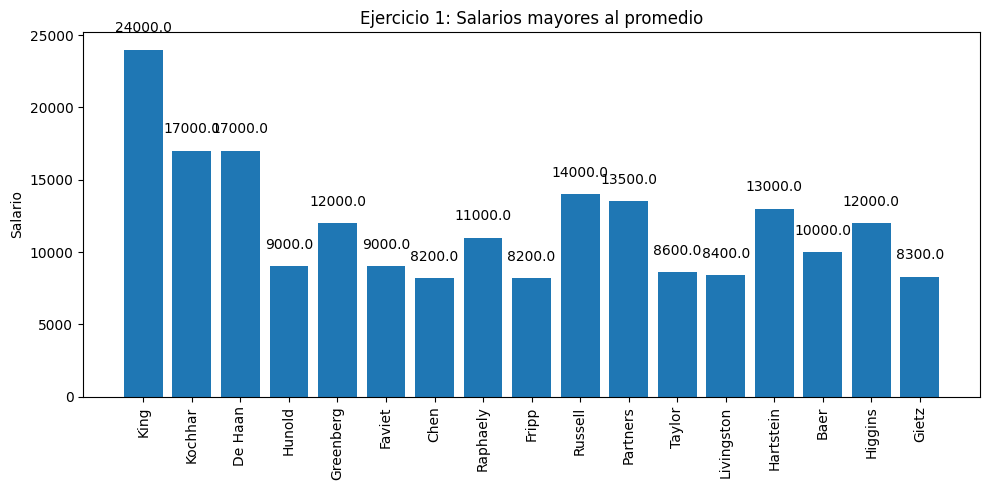

Ejercicio 2: [('King', 24000.0)]
Ejercicio 3: [('Purchasing', 6), ('Shipping', 7), ('IT', 5), ('Sales', 6), ('Finance', 6)]


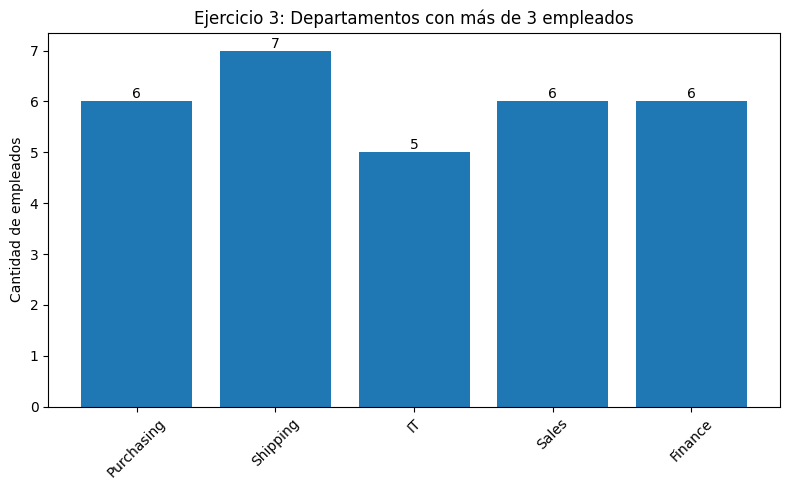

Ejercicio 4: [(6, 4), (10, 5), (3, 5), (5, 5), (8, 6), (1, 1), (2, 1), (4, 1), (7, 1), (11, 1)]
Ejercicio 5: [(9, 3), (1, 1), (2, 2), (4, 1), (7, 1), (11, 2)]
Ejercicio 6: [('King', 24000.0)]
Ejercicio 7: [('Ernst', 6000.0), ('Austin', 4800.0), ('Pataballa', 4800.0), ('Lorentz', 4200.0), ('Khoo', 3100.0), ('Baida', 2900.0), ('Tobias', 2800.0), ('Himuro', 2600.0), ('Colmenares', 2500.0), ('Mikkilineni', 2700.0), ('Johnson', 6200.0), ('Bell', 4000.0), ('Everett', 3900.0), ('Whalen', 4400.0), ('Fay', 6000.0)]
Ejercicio 8: []
Ejercicio 9: []
Ejercicio 10: [(2, 1), (3, 1), (5, 4), (6, 2), (8, 2), (9, 1), (10, 2), (11, 1)]
Conexión cerrada correctamente


In [3]:
import oracledb
import matplotlib.pyplot as plt

conn = oracledb.connect(
    user="hr",
    password="camila2004",
    dsn="localhost:1521/xe"
)
cursor = conn.cursor()
print("Conectado correctamente a Oracle")

# EJERCICIO 1: Salarios mayores al promedio (con gráfico)
cursor.execute("SELECT last_name, salary FROM employees WHERE salary > (SELECT AVG(salary) FROM employees)")
datos = cursor.fetchall()
print("Ejercicio 1:", datos)
nombres = [f[0] for f in datos]
salarios = [f[1] for f in datos]
plt.figure(figsize=(10,5))
bars = plt.bar(nombres, salarios)
plt.xticks(rotation=90)
plt.title("Ejercicio 1: Salarios mayores al promedio")
plt.ylabel("Salario")
for i, bar in enumerate(bars):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000, f"{salarios[i]}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# EJERCICIO 2: Empleados con mismo job_id que Steven King (solo mostrar)
cursor.execute("SELECT last_name, salary FROM employees WHERE job_id = (SELECT job_id FROM employees WHERE first_name='Steven' AND last_name='King')")
datos = cursor.fetchall()
print("Ejercicio 2:", datos)

# EJERCICIO 3: Departamentos con más de 3 empleados (con gráfico)
cursor.execute("SELECT d.department_name, COUNT(e.employee_id) FROM departments d JOIN employees e ON e.department_id = d.department_id GROUP BY d.department_name HAVING COUNT(e.employee_id) > 3")
datos = cursor.fetchall()
print("Ejercicio 3:", datos)
deptos = [f[0] for f in datos]
cantidad = [f[1] for f in datos]
plt.figure(figsize=(8,5))
bars = plt.bar(deptos, cantidad)
plt.title("Ejercicio 3: Departamentos con más de 3 empleados")
plt.ylabel("Cantidad de empleados")
plt.xticks(rotation=45)
for i, bar in enumerate(bars):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{cantidad[i]}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# EJERCICIO 4: Empleados que no son managers (solo mostrar)
cursor.execute("SELECT department_id, COUNT(*) FROM employees WHERE employee_id NOT IN (SELECT manager_id FROM employees WHERE manager_id IS NOT NULL) GROUP BY department_id")
datos = cursor.fetchall()
print("Ejercicio 4:", datos)

# EJERCICIO 5: Departamentos con menos de 4 empleados (solo mostrar)
cursor.execute("SELECT department_id, COUNT(*) FROM employees GROUP BY department_id HAVING COUNT(*) < 4")
datos = cursor.fetchall()
print("Ejercicio 5:", datos)

# EJERCICIO 6: Empleados con salario máximo (solo mostrar)
cursor.execute("SELECT last_name, salary FROM employees WHERE salary = (SELECT MAX(salary) FROM employees)")
datos = cursor.fetchall()
print("Ejercicio 6:", datos)

# EJERCICIO 7: Salarios menores que cualquier manager (solo mostrar)
cursor.execute("SELECT last_name, salary FROM employees WHERE salary < (SELECT MIN(salary) FROM employees WHERE employee_id IN (SELECT manager_id FROM employees WHERE manager_id IS NOT NULL))")
datos = cursor.fetchall()
print("Ejercicio 7:", datos)

# EJERCICIO 8: Departamentos sin empleados (solo mostrar)
cursor.execute("SELECT d.department_name FROM departments d LEFT JOIN employees e ON e.department_id = d.department_id GROUP BY d.department_name HAVING COUNT(e.employee_id) = 0")
datos = cursor.fetchall()
print("Ejercicio 8:", datos)

# EJERCICIO 9: Empleados en la misma ubicación que el depto 90 (solo mostrar)
cursor.execute("SELECT e.last_name, e.salary FROM employees e JOIN departments d ON e.department_id = d.department_id WHERE d.location_id = (SELECT location_id FROM departments WHERE department_id = 90)")
datos = cursor.fetchall()
print("Ejercicio 9:", datos)

# EJERCICIO 10: Empleados sobre el promedio por departamento (solo mostrar)
cursor.execute("SELECT department_id, COUNT(*) FROM employees e WHERE salary > (SELECT AVG(salary) FROM employees WHERE department_id = e.department_id) GROUP BY department_id")
datos = cursor.fetchall()
print("Ejercicio 10:", datos)

cursor.close()
conn.close()
print("Conexión cerrada correctamente")
